In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import os

In [3]:
ddir = r"C:\Users\ryansenne\Desktop\Dill"

cxt_a_dir = os.path.join(ddir, "cxta_traces_csv")
cxt_b_dir = os.path.join(ddir, "cxtb_traces_csv")

In [32]:
cxt_a_freezing = [file for file in os.listdir(cxt_a_dir) if "freeze_vec" in file]
cxt_b_freezing = [file for file in os.listdir(cxt_b_dir) if "freeze_vec" in file]

cxt_a_events = [file for file in os.listdir(cxt_a_dir) if "events_binary" in file]
cxt_b_events = [file for file in os.listdir(cxt_b_dir) if "events_binary" in file]

In [33]:
freeze_event_dict = {}

animal_ids = []
contexts = []
freeze_events = []
freeze_non_events = []

for freeze, event in zip(cxt_a_freezing, cxt_a_events):
    file_parts = freeze.split("_")
    animal_id = file_parts[0]

    freeze_file = pd.read_csv(os.path.join(cxt_a_dir, freeze))[99:].to_numpy().flatten()
    event_file = pd.read_csv(os.path.join(cxt_a_dir, event)).to_numpy().flatten()

    n_freeze = len(freeze_file)
    n_event = len(event_file)

    # getting a one off error cause of a header so just doing this little trick
    min_length = min(n_freeze, n_event)
    
    freeze_file = freeze_file[:min_length]
    event_file = event_file[:min_length]
    
    # Get freezing values when event vector is zero (no event detected)
    freezing_during_non_events = freeze_file[event_file == 0]
    freeze_during_events = freeze_file[event_file == 1]
    
    # Calculate average
    avg_freezing_non = np.mean(freezing_during_non_events)
    avg_freezing_during = np.mean(freeze_during_events)

    # append to respective lists
    animal_ids.append(animal_id)
    freeze_non_events.append(avg_freezing_non)
    freeze_events.append(avg_freezing_during)
    contexts.append("A")

for freeze, event in zip(cxt_b_freezing, cxt_b_events):
    file_parts = freeze.split("_")
    animal_id = file_parts[0]
    
    freeze_file = pd.read_csv(os.path.join(cxt_b_dir, freeze))[99:].to_numpy().flatten()
    event_file = pd.read_csv(os.path.join(cxt_b_dir, event)).to_numpy().flatten()

    n_freeze = len(freeze_file)
    n_event = len(event_file)

    # getting a one off error cause of a header so just doing this little trick
    min_length = min(n_freeze, n_event)
    
    freeze_file = freeze_file[:min_length]
    event_file = event_file[:min_length]
    
    # Get freezing values when event vector is zero (no event detected)
    freezing_during_non_events = freeze_file[event_file == 0]
    freezing_during_events = freeze_file[event_file == 1]
    
    # Calculate average
    avg_freezing_non = np.mean(freezing_during_non_events)
    avg_freezing_during = np.mean(freezing_during_events)

    # append to respective lists
    animal_ids.append(animal_id)
    freeze_non_events.append(avg_freezing_non)
    freeze_events.append(avg_freezing_during)
    contexts.append("B")


freeze_event_dict["Animal_ID"] = animal_ids
freeze_event_dict["Context"] = contexts
freeze_event_dict["Freeze_During_Events"] = freeze_events
freeze_event_dict["Freeze_During_Non_Events"] = freeze_non_events

freeze_df = pd.DataFrame(freeze_event_dict)

In [35]:
freeze_file = pd.read_csv(os.path.join(cxt_a_dir, "astroM9_freeze_vec_cxt_a.csv"))[99:].to_numpy().flatten()

In [37]:
freeze_df.to_csv(r"C:\Users\ryansenne\Desktop\Dill\freeze_event_analysis.csv")

In [42]:
freeze_a = freeze_df[freeze_df["Context"] == "A"]
freeze_b = freeze_df[freeze_df["Context"] == "B"]

long_a = pd.melt(freeze_a, id_vars=["Animal_ID"], value_vars=["Freeze_During_Events", "Freeze_During_Non_Events"],
                    var_name="Condition", value_name="Freezing_Level")

long_b = pd.melt(freeze_b, id_vars=["Animal_ID"], value_vars=["Freeze_During_Events", "Freeze_During_Non_Events"],
                    var_name="Condition", value_name="Freezing_Level")

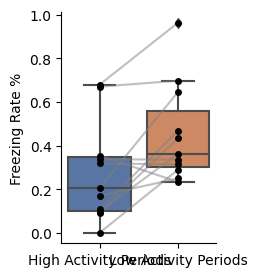

In [59]:
seq_a_plot, seq_a_ax = plt.subplots(figsize=(2,3))
sns.boxplot(data=long_a, x="Condition", y="Freezing_Level", ax=seq_a_ax)
sns.stripplot(data=long_a, x="Condition", y="Freezing_Level", color='black', dodge=False, jitter=False, ax=seq_a_ax)

# plot lines between points
for animal in freeze_a["Animal_ID"].unique():
    animal_data = long_a[long_a["Animal_ID"] == animal]
    seq_a_ax.plot(animal_data["Condition"], animal_data["Freezing_Level"], color='gray', alpha=0.5)


seq_a_ax.set_ylabel("Freezing Rate %")
seq_a_ax.set_xlabel("")

seq_a_ax.set_xticklabels(["High Activity Periods", "Low Activity Periods"])

plt.savefig(r"C:\Users\ryansenne\Desktop\dCA1_Figures\CxtA_Seq_Freezing.svg", transparent=True)

In [68]:
arcsinsqrt = lambda p: np.arcsin(np.sqrt(p))

In [80]:
# test the differences and include sex info

long_a["Sex"] = long_a["Animal_ID"].apply(lambda x: "M" if "M" in x else "F")
long_a["Freeze_Arcsin_Sqrt"] = long_a["Freezing_Level"].apply(lambda x: arcsinsqrt(x))

model = smf.mixedlm("Freeze_Arcsin_Sqrt ~ Condition*Sex", data=long_a, groups=long_a["Animal_ID"])
model.fit().summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Mixed Linear Model Regression Results
=========================================================================================
Model:                     MixedLM         Dependent Variable:         Freeze_Arcsin_Sqrt
No. Observations:          22              Method:                     REML              
No. Groups:                11              Scale:                      0.0271            
Min. group size:           2               Log-Likelihood:             -3.7130           
Max. group size:           2               Converged:                  Yes               
Mean group size:           2.0                                                           
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                       0.547    0.116  4.702 0.000  0.319  0.775
Condition[T.Freeze_During_Non_Events]           0.154    0.095  1.616 0.106 -0.033  0.340
Sex[T.M]                                       -0.077    0.173 -0.449 0.654 -0.416  0.261
Condition[T.Freeze_During_Non_Events]:Sex[T.M]  0.180    0.141  1.275 0.202 -0.097  0.456
Group Var                                       0.054    0.274                           
=========================================================================================

"""

In [70]:
long_a

,Animal_ID,Condition,Freezing_Level,Sex,Freeze_Logit
0,astroF10,Freeze_During_Events,0.204969,F,0.469830
1,astroF3,Freeze_During_Events,0.669811,F,0.958656
2,astroF5,Freeze_During_Events,0.317647,F,0.598740
3,astroF6,Freeze_During_Events,0.354167,F,0.637414
4,astroF7,Freeze_During_Events,0.336842,F,0.619196
5,astroF9,Freeze_During_Events,0.000000,F,0.000000
6,astroM10,Freeze_During_Events,0.679104,M,0.968573
7,astroM3,Freeze_During_Events,0.096685,M,0.316184
8,astroM4,Freeze_During_Events,0.169675,M,0.424556
9,astroM5,Freeze_During_Events,0.107143,M,0.333473


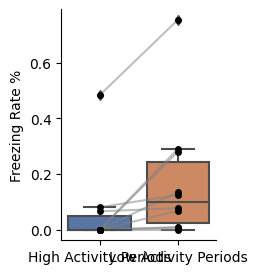

In [62]:
seq_b_plot, seq_b_ax = plt.subplots(figsize=(2,3))
sns.boxplot(data=long_b, x="Condition", y="Freezing_Level", ax=seq_b_ax)
sns.stripplot(data=long_b, x="Condition", y="Freezing_Level", color='black', dodge=False, jitter=False, ax=seq_b_ax)

# plot lines between points
for animal in freeze_b["Animal_ID"].unique():
    animal_data = long_b[long_b["Animal_ID"] == animal]
    seq_b_ax.plot(animal_data["Condition"], animal_data["Freezing_Level"], color='gray', alpha=0.5)


seq_b_ax.set_ylabel("Freezing Rate %")
seq_b_ax.set_xlabel("")

seq_b_ax.set_xticklabels(["High Activity Periods", "Low Activity Periods"])

plt.savefig(r"C:\Users\ryansenne\Desktop\dCA1_Figures\CxtB_Seq_Freezing.svg", transparent=True)

In [39]:
from scipy.stats import ttest_rel

ttest_rel(freeze_df[freeze_df["Context"] == "A"]["Freeze_During_Events"],
            freeze_df[freeze_df["Context"] == "A"]["Freeze_During_Non_Events"])

TtestResult(statistic=-3.176311812472267, pvalue=0.009881145463381034, df=10)